simulating p90 values from a mean and std

In [ ]:
import scipy.stats
def z2p(z):
    p_value = scipy.stats.norm.sf(abs(z))
    return p_value

In [ ]:
from scipy.stats import norm
mean = 50
std = 10
perc = .90
percvalue = norm.ppf(perc, loc=mean, scale=std)
percvalue


90th percentile value: 62.815515655446006


now do that on a raster

In [1]:
import xarray as xr
ds = xr.open_dataset(r"C:\Data\ros\ros_rasters.nc")

In [ ]:
ds.data_vars
mean = list(ds.data_vars)[1]
std = list(ds.data_vars)[3]

'ros-anrainonsnow10_CanRCM4_historical_1976-2005_annstd_30yavg.nc'

In [36]:
renamed = mean.replace("annmean", "annp90sim")
renamed

'ros-anrainonsnow10_CanRCM4_historical_1976-2005_annp90sim_30yavg.nc'

In [ ]:
# create coupled list of means and stds data var names, assuming dataset has all 5 created
means = []
stds = []
for n in range(len(ds.data_vars)):
    if n % 5 == 1: means.append(list(ds.data_vars)[n])
    if n % 5 == 3: stds.append(list(ds.data_vars)[n])

In [20]:
dmean, dstd = xr.align(ds[mean], ds[std])

In [28]:
percentile_90 = xr.apply_ufunc(norm.ppf, xr.DataArray(0.90), dmean, dstd, vectorize=True, output_core_dims=[[]])
percentile_90


c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


<xarray.DataArray (lat: 638, lon: 1476)> Size: 8MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(638, 1476))
Coordinates:
    rotated_pole        |S1 1B b''
  * lon                 (lon) float64 12kB 189.3 189.4 189.5 ... 336.7 336.8
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 5kB 12.17 12.27 12.37 ... 75.77 75.87

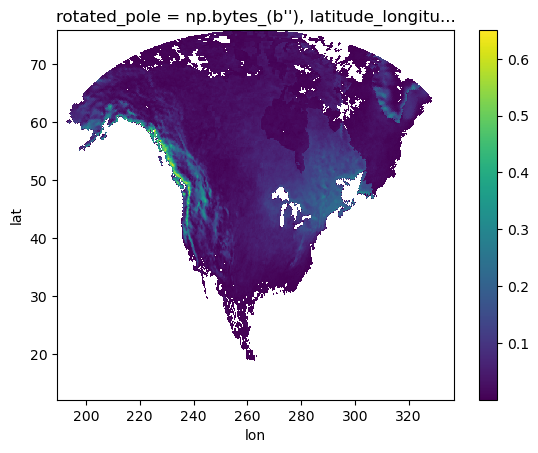

In [29]:
percentile_90.plot()

c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\CAMG038492\AppData\Local\miniforge3\envs\climate\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


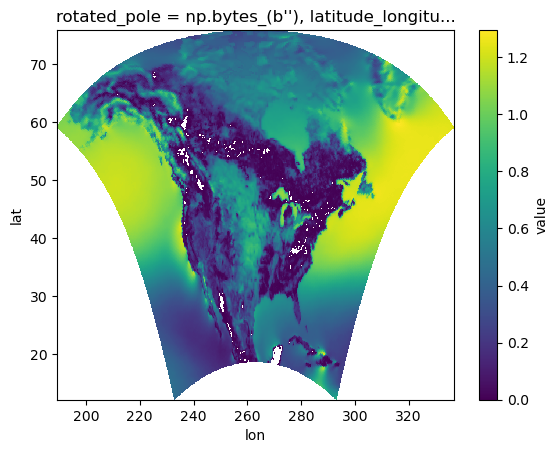

In [7]:
import xarray as xr
from scipy.stats import norm
dmean = xr.open_dataset(r"C:\Data\sfcWindmax\historical\rasters\sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yavg.nc")
dstd = xr.open_dataset(r"C:\Data\sfcWindmax\historical\rasters\sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annstd_30yavg.nc")
#dmean = dmean.fillna(0.)
#dstd = dmean.fillna(0.)
perc_90 = xr.apply_ufunc(norm.ppf, xr.DataArray(0.90), dmean, dstd, vectorize=True, output_core_dims=[[]], output_dtypes=[float])
perc_90.value.plot()

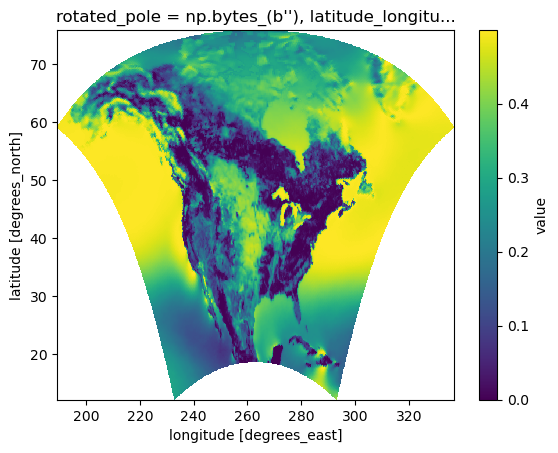

In [9]:
dstd.value.plot()

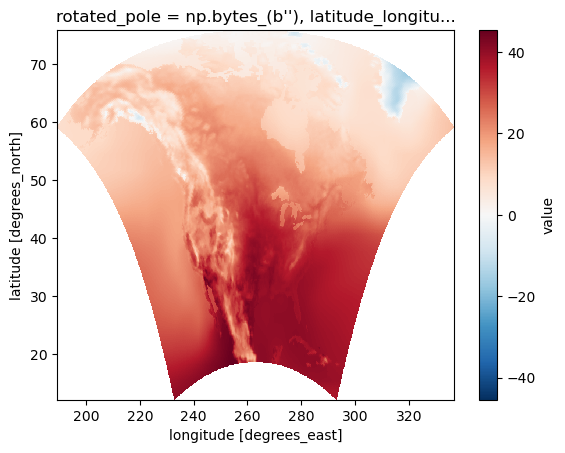

In [3]:
import xarray as xr
path =  r"C:\Data\humidex\historical\rasters\humidex_CanRCM4_historical_p90sim_1976-2005_annp90sim_30yavg.nc"
ds = xr.open_dataset(path)
ds.value.plot()

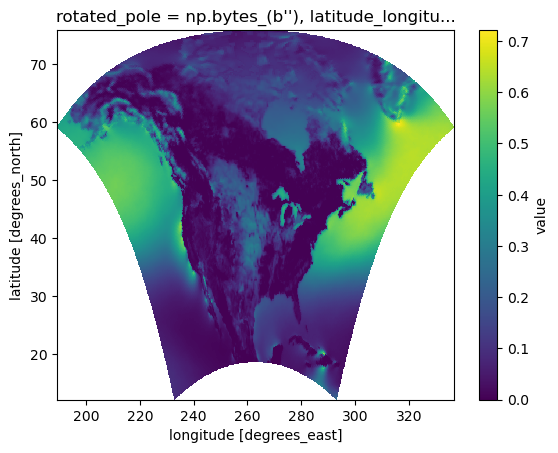

In [4]:
import xarray as xr
look1 = xr.open_dataset(r"C:\Data\sfcWindmax\historical\rasters\sfcWindmax-anwindgust63_CanRCM4_historical_1976-2005_annmean_30yp90.nc")
look2 = xr.open_dataset(r"C:\Data\sfcWindmax\historical\rasters\sfcWindmax-anwindgust63_CanRCM4_historical_p90sim_1976-2005_annp90sim_30yavg.nc")
look1.value.plot()